In [1]:
import pandas as pd

df = pd.read_csv("trainTrackA.csv")

print(df.head())
print(df.columns)
print(df.info())

     basin                 date  longwave_radiation  potential_energy  \
0  8178880  2005-01-01 00:00:00           331.56604         14.244372   
1  8178880  2005-01-01 01:00:00           331.56583          9.645018   
2  8178880  2005-01-01 02:00:00           331.56952          5.048748   
3  8178880  2005-01-01 03:00:00           348.38947          0.450123   
4  8178880  2005-01-01 04:00:00           348.39133          3.453815   

   potential_evaporation   pressure  shortwave_radiation  specific_humidity  \
0               0.287952  95618.450                  0.0           0.010157   
1               0.029872  95551.100                  0.0           0.010148   
2               0.029872  95483.920                  0.0           0.010139   
3               0.029872  95416.805                  0.0           0.010130   
4               0.035448  95472.860                  0.0           0.010233   

   temperature  total_precipitation  ...  area_geospa_fabric  frac_forest  \
0    18.6

# Deep Learning Project: Hourly Streamflow Forecasting using LSTM

## Student Name: 1)DLX - 2216093, 2211203, 2217275
## Course: Deep Learning
## Assessment 1: Problem Understanding & Baseline

This notebook presents a baseline deep learning model for hourly river streamflow forecasting using the Track A dataset from the Kaggle Hourly River Streamflow Forecasting Hackathon.

### Target Variable
The target variable is `qobs_mm_per_hour`, which represents observed streamflow in mm per hour.

### Input Data
The dataset contains hourly meteorological variables, basin information, and catchment attributes.

### Tasks Covered
- Problem understanding
- Dataset overview
- Exploratory Data Analysis (EDA)
- Baseline LSTM implementation
- Model evaluation using RMSE

In [2]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
# =========================================================
# 2. LOAD DATA
# =========================================================
df = pd.read_csv("trainTrackA.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (482040, 55)
     basin                 date  longwave_radiation  potential_energy  \
0  8178880  2005-01-01 00:00:00           331.56604         14.244372   
1  8178880  2005-01-01 01:00:00           331.56583          9.645018   
2  8178880  2005-01-01 02:00:00           331.56952          5.048748   
3  8178880  2005-01-01 03:00:00           348.38947          0.450123   
4  8178880  2005-01-01 04:00:00           348.39133          3.453815   

   potential_evaporation   pressure  shortwave_radiation  specific_humidity  \
0               0.287952  95618.450                  0.0           0.010157   
1               0.029872  95551.100                  0.0           0.010148   
2               0.029872  95483.920                  0.0           0.010139   
3               0.029872  95416.805                  0.0           0.010130   
4               0.035448  95472.860                  0.0           0.010233   

   temperature  total_precipitation  ...  area_geospa_fabric  frac

In [4]:
# =========================================================
# 3. BASIC INFO
# =========================================================
print(df.columns)
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(10))

Index(['basin', 'date', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v', 'qobs_mm_per_hour', 'geol_1st_class', 'glim_1st_class_frac',
       'geol_2nd_class', 'glim_2nd_class_frac', 'carbonate_rocks_frac',
       'geol_porostiy', 'geol_permeability', 'p_mean', 'pet_mean',
       'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq',
       'high_prec_dur', 'low_prec_freq', 'low_prec_dur',
       'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity',
       'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac',
       'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'gauge_lat',
       'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2',
       'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max',
       'gvf_diff', 'dom_land_cover_frac', 'dom_land_cover', 'root_depth_50',
       'root

In [5]:
# =========================================================
# 4. PREPROCESSING
# =========================================================

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort by basin and time
df = df.sort_values(["basin", "date"]).reset_index(drop=True)

# Drop rows with missing values in important columns
df = df.dropna(subset=["qobs_mm_per_hour"])

# Fill remaining numeric missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Remove rows that still have missing values in selected important object columns if any
df = df.dropna().reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (482040, 55)


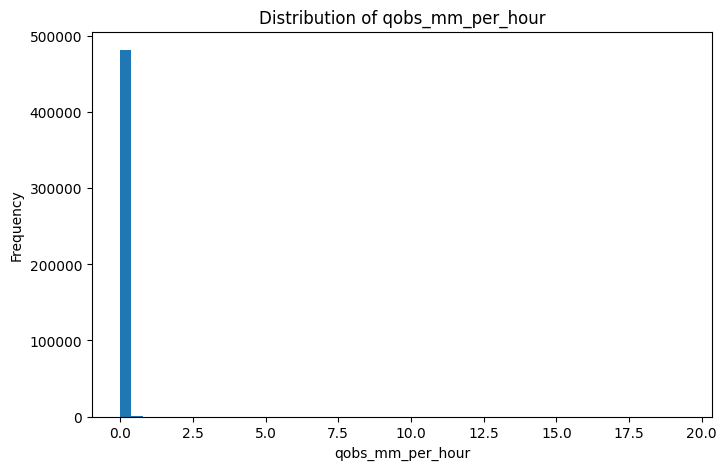

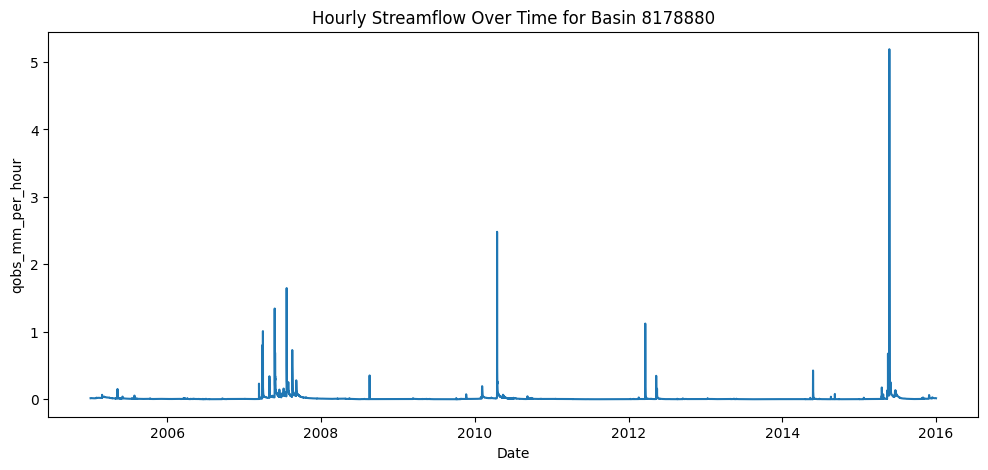

0


In [6]:
# =========================================================
# 5. SIMPLE EDA
# =========================================================

# Target distribution
plt.figure(figsize=(8,5))
plt.hist(df["qobs_mm_per_hour"], bins=50)
plt.title("Distribution of qobs_mm_per_hour")
plt.xlabel("qobs_mm_per_hour")
plt.ylabel("Frequency")
plt.show()

# Streamflow over time for one basin
sample_basin = df["basin"].iloc[0]
sample_df = df[df["basin"] == sample_basin]

plt.figure(figsize=(12,5))
plt.plot(sample_df["date"], sample_df["qobs_mm_per_hour"])
plt.title(f"Hourly Streamflow Over Time for Basin {sample_basin}")
plt.xlabel("Date")
plt.ylabel("qobs_mm_per_hour")
plt.show()

# Missing values check
print(df.isnull().sum().sum())

In [7]:
# =========================================================
# 6. FEATURE SELECTION
# =========================================================

# Drop categorical text columns for simple baseline
drop_cols = ["date", "qobs_mm_per_hour", "geol_1st_class", "geol_2nd_class", "dom_land_cover"]
feature_cols = [col for col in df.columns if col not in drop_cols]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 50
['basin', 'longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure', 'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v', 'glim_1st_class_frac', 'glim_2nd_class_frac', 'carbonate_rocks_frac', 'geol_porostiy', 'geol_permeability', 'p_mean', 'pet_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 'soil_depth_pelletier', 'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 'water_frac', 'organic_frac', 'other_frac', 'gauge_lat', 'gauge_lon', 'elev_mean', 'slope_mean', 'area_gages2', 'area_geospa_fabric', 'frac_forest', 'lai_max', 'lai_diff', 'gvf_max', 'gvf_diff', 'dom_land_cover_frac', 'root_depth_50', 'root_depth_99']


In [8]:
# =========================================================
# 7. OPTIONAL TARGET TRANSFORMATION
# =========================================================

# log1p helps reduce skewness in streamflow values
df["target_log"] = np.log1p(df["qobs_mm_per_hour"])

In [9]:
# =========================================================
# 8. TRAIN-VALIDATION SPLIT BY TIME
# =========================================================

train_parts = []
val_parts = []

for basin_id, basin_df in df.groupby("basin"):
    basin_df = basin_df.sort_values("date")
    split_idx = int(len(basin_df) * 0.8)
    train_parts.append(basin_df.iloc[:split_idx])
    val_parts.append(basin_df.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (385630, 56)
Validation shape: (96410, 56)


In [10]:
# =========================================================
# 9. SCALE FEATURES
# =========================================================

scaler = StandardScaler()

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

In [11]:
# =========================================================
# 10. CREATE SEQUENCES FOR LSTM
# =========================================================

SEQ_LEN = 24  # use previous 24 hours

def create_sequences(dataframe, feature_cols, target_col="target_log", seq_len=24):
    X, y = [], []

    for basin_id, basin_df in dataframe.groupby("basin"):
        basin_df = basin_df.sort_values("date")
        X_values = basin_df[feature_cols].values
        y_values = basin_df[target_col].values

        for i in range(seq_len, len(basin_df)):
            X.append(X_values[i-seq_len:i])
            y.append(y_values[i])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, feature_cols, target_col="target_log", seq_len=SEQ_LEN)
X_val, y_val = create_sequences(val_df, feature_cols, target_col="target_log", seq_len=SEQ_LEN)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (385510, 24, 50)
y_train shape: (385510,)
X_val shape: (96290, 24, 50)
y_val shape: (96290,)


In [12]:
# =========================================================
# 11. BUILD BASELINE LSTM MODEL
# =========================================================

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,553 (123.25 KB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# =========================================================
# 12. TRAIN MODEL
# =========================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 9.9510e-04 - val_loss: 0.0013
Epoch 2/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 4.9848e-04 - val_loss: 9.8889e-04
Epoch 3/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 4.4807e-04 - val_loss: 0.0011
Epoch 4/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 4.1889e-04 - val_loss: 0.0010
Epoch 5/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 3.6786e-04 - val_loss: 0.0011
Epoch 6/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 3.1931e-04 - val_loss: 0.0011
Epoch 7/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 3.0436e-04 - val_loss: 0.0011


In [14]:
# =========================================================
# 13. EVALUATE MODEL
# =========================================================

y_pred_log = model.predict(X_val).flatten()

# Convert back to original scale
y_val_actual = np.expm1(y_val)
y_pred_actual = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred_actual))
print("Baseline Validation RMSE:", rmse)

3010/3010 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
Baseline Validation RMSE: 0.0670006960526018


In [ ]:
# =========================================================
# 14. PLOT TRAINING HISTORY
# =========================================================

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Dataset shape: (482040, 56)
basin                             int64
date                     datetime64[ns]
longwave_radiation              float64
potential_energy                float64
potential_evaporation           float64
pressure                        float64
shortwave_radiation             float64
specific_humidity               float64
temperature                     float64
total_precipitation             float64
wind_u                          float64
wind_v                          float64
qobs_mm_per_hour                float64
geol_1st_class                   object
glim_1st_class_frac             float64
geol_2nd_class                   object
glim_2nd_class_frac             float64
carbonate_rocks_frac            float64
geol_porostiy                   float64
geol_permeability               float64
p_mean                          float64
pet_mean                        float64
p_seasonality                   float64
frac_snow                       float64
aridity     

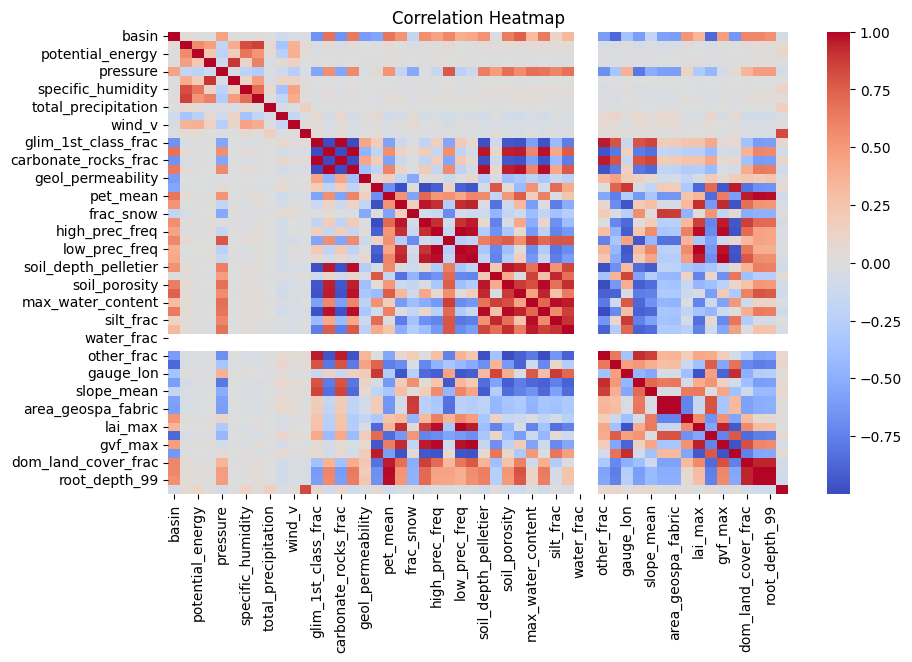

In [16]:
# =========================================================
# EXTRA EDA (IMPORTANT FOR MARKS)
# =========================================================

# 1. Data shape
print("Dataset shape:", df.shape)

# 2. Data types
print(df.dtypes)

# 3. Missing values (top 10)
print(df.isnull().sum().sort_values(ascending=False).head(10))

# 4. Summary statistics
print(df.describe())

# 5. Correlation heatmap (important)
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()